In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    utils,
    metrics,
    losses,
    optimizers,
)
import pandas as pd
import os

In [2]:
IMAGE_SIZE = 64
CHANNELS = 1
NUM_CONDITIONS = 2  # Pore %, Solid %
Z_DIM = 64
NUM_FEATURES = 64
LEARNING_RATE = 0.0005
BETA = 1000
EPOCHS = 200
BATCH_SIZE = 32


In [3]:
#Load Attributes and File Paths
attributes = pd.read_csv(r"C:\Users\E2021593.CEET\Desktop\Microstructure\normalised_area.csv")
labels = attributes[['Pore Percentage', 'Solid Percentage']].values

image_dir = r"C:\Users\E2021593.CEET\Desktop\Lithium Microstructures"
file_paths = [os.path.join(image_dir, fname) for fname in attributes['Image Name']]

#TF Dataset
def load_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
train_data = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [4]:
import matplotlib.pyplot as plt

def display(images, conditions=None, n=10, size=(20, 3), cmap="gray", as_type="float32", save_to=None):
    
    # Normalize the images if necessary
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    n = min(n, images.shape[0])
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")
        if conditions is not None:
            # Formatting the condition vector (e.g., [0.65, 0.20, 0.10, 0.05]) into a string.
            cond_str = ', '.join(f'{val:.2f}' for val in conditions[i])
            ax.set_title(cond_str, fontsize=8)
    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")
    plt.show()

In [5]:
def sample_batch(dataset):
    # Take one batch from the dataset
    batch = dataset.take(1).get_single_element()
    # Each batch is a tuple (images, conditions)
    images, conditions = batch
    return images.numpy(), conditions.numpy()

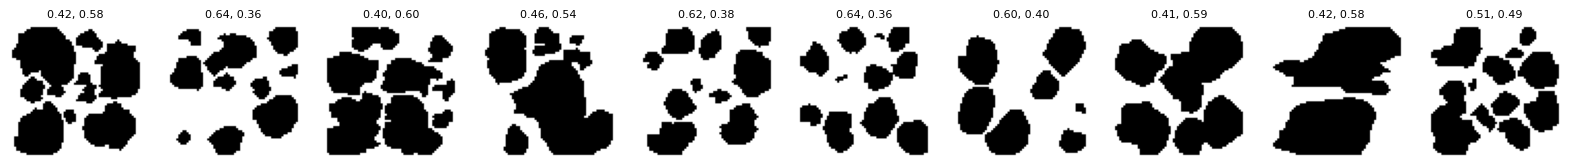

In [6]:
# Sample a batch from the training dataset (which now contains (image, condition) pairs)
images, conditions = sample_batch(train_data)

# Display the first 10 images with their condition vectors as titles.
display(images, conditions, n=10, size=(20, 3), cmap='gray')


In [7]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


In [8]:
#Encoder
encoder_img_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), name="encoder_img")
encoder_cond_input = layers.Input(shape=(NUM_CONDITIONS,), name="encoder_cond")

# Block 1:
x = layers.Conv2D(NUM_FEATURES, 3, strides=2, padding="same")(encoder_img_input)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 2:
x = layers.Conv2D(NUM_FEATURES * 2, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 3:
x = layers.Conv2D(NUM_FEATURES * 2, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 4:
x = layers.Conv2D(NUM_FEATURES * 4, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 5:
x = layers.Conv2D(NUM_FEATURES * 4, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

shape_before_flattening = tf.keras.backend.int_shape(x)[1:]

x = layers.Flatten()(x)
cond_dense = layers.Dense(64, activation="relu")(encoder_cond_input)
x = layers.concatenate([x, cond_dense])

z_mean = layers.Dense(Z_DIM, name="z_mean")(x)
z_log_var = layers.Dense(Z_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = models.Model([encoder_img_input, encoder_cond_input], [z_mean, z_log_var, z], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_img (InputLayer)      │ (None, 64, 64, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 32, 32, 64)        │             640 │ encoder_img[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 32, 32, 64)        │             256 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu (LeakyReLU)       │ (None, 32, 32, 64)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 16, 16, 128)       │          73,856 │ leaky_re_lu[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 16, 16, 128)       │             512 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU)     │ (None, 16, 16, 128)       │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 8, 8, 128)         │         147,584 │ leaky_re_lu_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 8, 8, 128)         │             512 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU)     │ (None, 8, 8, 128)         │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 4, 4, 256)         │         295,168 │ leaky_re_lu_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 4, 4, 256)         │           1,024 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU)     │ (None, 4, 4, 256)         │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 2, 2, 256)         │         590,080 │ leaky_re_lu_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 2, 2, 256)         │           1,024 │ conv2d_4[0][0]             │
│ (BatchNormalization)          │                           │               

 Total params: 1,250,240 (4.77 MB)

 Trainable params: 1,248,576 (4.76 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [9]:
decoder_z_input = layers.Input(shape=(Z_DIM,), name="decoder_z")
decoder_cond_input = layers.Input(shape=(NUM_CONDITIONS,), name="decoder_cond")


cond_dense_dec = layers.Dense(64, activation='relu')(decoder_cond_input)
x = layers.concatenate([decoder_z_input, cond_dense_dec])
x = layers.Dense(np.prod(shape_before_flattening))(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Reshape(shape_before_flattening)(x)

# Block 1:
x = layers.Conv2DTranspose(NUM_FEATURES * 4, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 2:
x = layers.Conv2DTranspose(NUM_FEATURES * 4, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 3:
x = layers.Conv2DTranspose(NUM_FEATURES * 2, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 4:
x = layers.Conv2DTranspose(NUM_FEATURES * 2, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 5:
x = layers.Conv2DTranspose(NUM_FEATURES, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

decoder_output = layers.Conv2DTranspose(CHANNELS, 3, strides=1, activation="sigmoid", padding="same")(x)

decoder = models.Model([decoder_z_input, decoder_cond_input], decoder_output, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ decoder_cond (InputLayer)     │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_z (InputLayer)        │ (None, 64)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │             192 │ decoder_cond[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 128)               │               0 │ decoder_z[0][0],           │
│                               │                           │                 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 1024)              │         132,096 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 1024)              │           4,096 │ dense_2[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU)     │ (None, 1024)              │               0 │ batch_normalization_5[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 2, 2, 256)         │               0 │ leaky_re_lu_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose              │ (None, 4, 4, 256)         │         590,080 │ reshape[0][0]              │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 4, 4, 256)         │           1,024 │ conv2d_transpose[0][0]     │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_6 (LeakyReLU)     │ (None, 4, 4, 256)         │               0 │ batch_normalization_6[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_1            │ (None, 8, 8, 256)         │         590,080 │ leaky_re_lu_6[0][0]        │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_7         │ (None, 8, 8, 256)         │           1,024 │ conv2d_transpose_1[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_7 (LeakyReLU)     │ (None, 8, 8, 256)         │               0 │ batch_normalization_7[0][… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 1,836,865 (7.01 MB)

 Trainable params: 1,833,153 (6.99 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [10]:
class CVAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        img, cond = inputs
        z_mean, z_log_var, z = self.encoder([img, cond])
        reconstruction = self.decoder([z, cond])
        return z_mean, z_log_var, reconstruction

    def train_step(self, data):
        img, cond = data
        
        with tf.GradientTape() as tape:
            # Forward pass
            z_mean, z_log_var, reconstruction = self([img, cond], training=True)
            
            # Manual MSE calculation
            pixel_wise_error = img - reconstruction
            squared_error = tf.square(pixel_wise_error)
            reconstruction_loss = tf.reduce_mean(BETA * squared_error)
            
            # KL Divergence calculation
            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
            kl_loss = tf.reduce_mean(kl_loss)
            
            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Backpropagation
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [11]:
cvae = CVAE(encoder, decoder)
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)
cvae.compile(optimizer=optimizer)

In [12]:
# Callbacks
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./cvae_checkpoint.keras",
    save_weights_only=False,
    save_freq="epoch",
    monitor="loss",
    mode="min",
    save_best_only=True,
    verbose=0,
)


In [13]:
history = cvae.fit(
    train_data,
    epochs=EPOCHS,
    callbacks=[model_checkpoint_callback]
)

Epoch 1/200
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1055s 335ms/step - kl_loss: 24.0162 - loss: 148.1848 - reconstruction_loss: 124.1685
Epoch 2/200
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1123s 359ms/step - kl_loss: 36.2189 - loss: 120.4741 - reconstruction_loss: 84.2552
Epoch 3/200
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1124s 359ms/step - kl_loss: 37.5364 - loss: 118.5657 - reconstruction_loss: 81.0292
Epoch 4/200
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1124s 360ms/step - kl_loss: 38.4087 - loss: 117.4646 - reconstruction_loss: 79.0559
Epoch 5/200
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1122s 359ms/step - kl_loss: 38.9416 - loss: 116.8423 - reconstruction_loss: 77.9008
Epoch 6/200
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1125s 360ms/step - kl_loss: 39.2791 - loss: 116.3721 - reconstruction_loss: 77.0929
Epoch 7/200
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1128s 361ms/step - kl_loss: 39.5506 - loss: 116.0231 - reconstruction_loss: 76.4726
Epoch 8/200
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1123s 359ms/step - kl_loss: 39.6768 - loss: 115.6680 - reconstructi

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Original Images


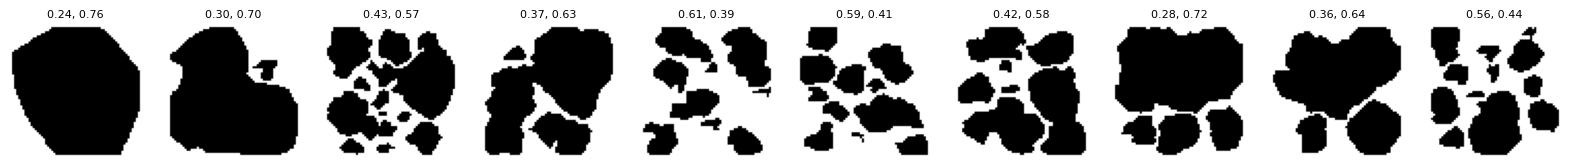

Reconstructions


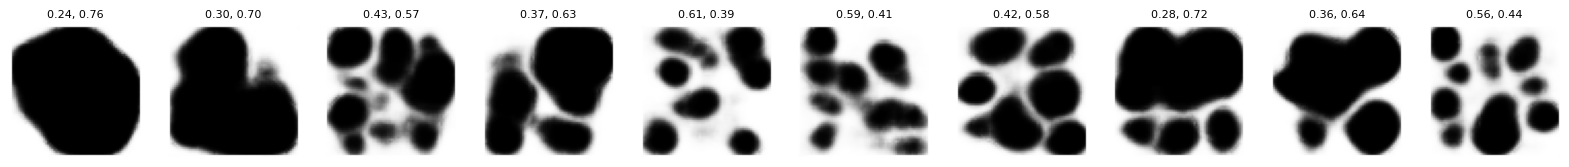

In [19]:
for example_batch in train_data.take(1):
    example_images, example_conditions = example_batch
    break  # We only need one batch

# Convert to numpy arrays 
example_images_np = example_images.numpy()
example_conditions_np = example_conditions.numpy()

#Get Reconstructions 
z_mean, z_log_var, reconstructions = cvae.predict([example_images_np, example_conditions_np])

#Display Original Images and Their Reconstructions
print("Original Images")
display(example_images_np, conditions=example_conditions_np, n=10, size=(20, 3))
print("Reconstructions")
display(reconstructions, conditions=example_conditions_np, n=10, size=(20, 3))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


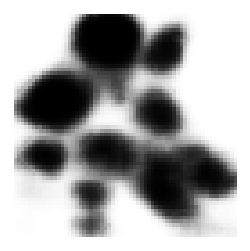

In [20]:
z_random = np.random.normal(size=(1, Z_DIM))
condition = np.array([[0.60, 0.40]])  # e.g., 60% pore
generated_image = decoder.predict([z_random, condition])
display(generated_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


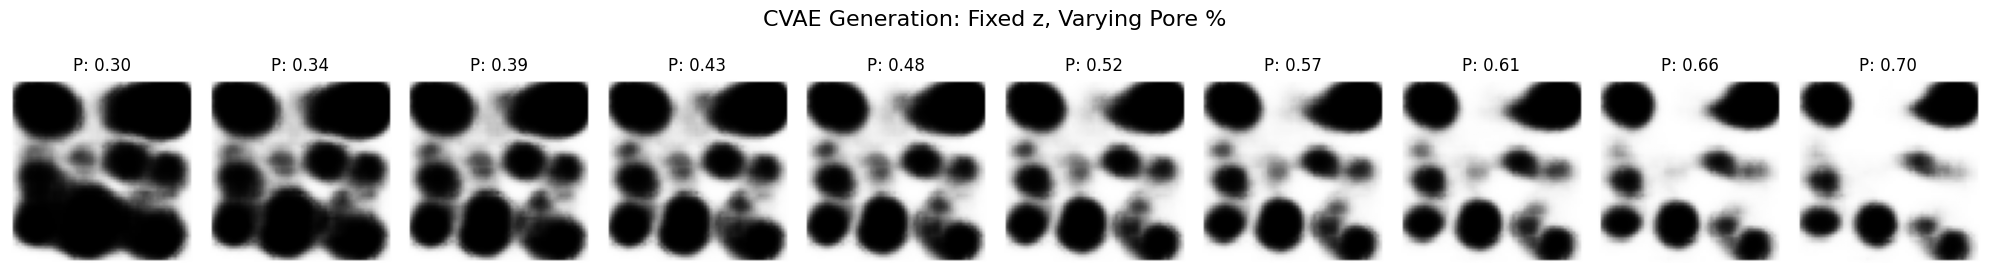

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Fix the latent vector (z)
z_fixed = np.random.normal(size=(1, Z_DIM))  # or use np.zeros((1, Z_DIM)) for deterministic output

# Sweep conditions from 0.30 to 0.70 (pore %), solid = 1 - pore
pore_values = np.linspace(0.30, 0.70, num=10)  # 10 steps
condition_list = [[p, 1 - p] for p in pore_values]
condition_array = np.array(condition_list)

# Repeat the same z for each condition
z_repeat = np.repeat(z_fixed, len(condition_array), axis=0)

# Generate images
generated_images = decoder.predict([z_repeat, condition_array])

# Plot results
plt.figure(figsize=(20, 3))
for i in range(len(pore_values)):
    ax = plt.subplot(1, len(pore_values), i + 1)
    plt.imshow(generated_images[i, :, :, 0], cmap='gray')
    plt.axis('off')
    plt.title(f"P: {pore_values[i]:.2f}")
plt.suptitle("CVAE Generation: Fixed z, Varying Pore %", fontsize=16)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


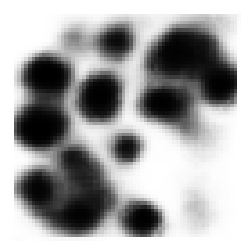

In [22]:
z = np.random.normal(size=(1, Z_DIM))  # sample latent vector
condition = np.array([[0.58, 0.41]])
generated_image = decoder.predict([z, condition])

display(generated_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


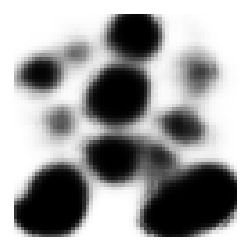

In [23]:
z = np.random.normal(size=(1, Z_DIM))  # sample latent vector
condition = np.array([[0.57, 0.42]])
generated_image = decoder.predict([z, condition])

display(generated_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


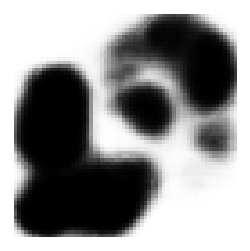

In [25]:
z = np.random.normal(size=(1, Z_DIM))  # sample latent vector
condition = np.array([[0.50, 0.50]])
generated_image = decoder.predict([z, condition])

display(generated_image)